In [3]:
import copy
import os
import pandas as pd
import requests
import re
from bs4 import BeautifulSoup, NavigableString, Tag
from tqdm import tqdm

In [4]:
from pathlib import Path

def iter_case_soups(input_folder=None, pattern="*.html", limit=None):
    """Yield (html_path, BeautifulSoup) from an input folder of HTML files.

    Args:
        input_folder (str | Path | None): folder containing HTML files.
            - If None, defaults to current working directory.
        pattern (str): glob pattern, default '*.html'.
        limit (int | None): optional max number of files to parse.
    """
    folder = Path(input_folder) if input_folder is not None else Path.cwd()

    if not folder.exists() or not folder.is_dir():
        raise FileNotFoundError(f"Input folder not found or not a directory: {folder}")

    files = sorted(folder.glob(pattern))
    if limit is not None:
        files = files[:limit]

    for html_path in files:
        html = html_path.read_text(encoding="utf-8", errors="ignore")
        soup = BeautifulSoup(html, "html.parser")
        yield html_path, soup

In [9]:
import pandas as pd
from bs4 import BeautifulSoup
import re
import json
from io import StringIO

def process_echr_document(raw_html, is_decision=False):
    """
    The Master Pipeline: Extracts tables, converts text to KG-optimized Markdown, 
    chunks into specific legal sections, and purges Questions.
    """
    
    # ---------------------------------------------------------
    # STEP 1: Extract Tables
    # ---------------------------------------------------------
    extracted_tables = []
    try:
        dfs = pd.read_html(StringIO(raw_html), flavor="lxml")
        for i, df in enumerate(dfs):
            df = df.dropna(how='all', axis=0).dropna(how='all', axis=1)
            if not df.empty:
                extracted_tables.append({f"table_{i+1}": df.to_dict(orient='records')})
    except ValueError:
        pass

    # ---------------------------------------------------------
    # STEP 2: Convert HTML to KG-Optimized Markdown
    # ---------------------------------------------------------
    soup = BeautifulSoup(raw_html, 'html.parser')
    
    for tag in soup(['style', 'script', 'meta', 'link', 'table']):
        tag.decompose()

    _block_tags = {'p', 'h1', 'h2', 'h3', 'h4', 'div'}

    markdown_lines = []
    for element in soup.find_all(['p', 'h1', 'h2', 'h3', 'div']):
        if element.name == 'div' and element.find(_block_tags):
            continue

        text = element.get_text(separator=" ", strip=True)
        if not text:
            continue

        text = re.sub(r'\s+', ' ', text)
        
        is_bold = element.find('b') is not None or element.find('strong') is not None
        is_all_caps = text.isupper() and len(text) > 4
        
        if is_all_caps and is_bold and len(text) < 100:
            markdown_lines.append(f"\n# {text}\n")
        elif (is_bold and len(text) < 150) or (is_all_caps and len(text) < 150):
            markdown_lines.append(f"\n## {text}\n")
        else:
            match = re.match(r'^(\d+\.)\s*(.*)', text)
            if match:
                markdown_lines.append(f"**{match.group(1)}** {match.group(2)}")
            else:
                markdown_lines.append(text)

    full_markdown = "\n".join(markdown_lines)

    # ---------------------------------------------------------
    # STEP 3: Chunk the Markdown into Logical Buckets
    # ---------------------------------------------------------
    chunks = {
        "introduction": "",
        "procedure": "",
        "facts": "",
        "legal_framework": "",
        "law": "",
        "reasons": "",
        "appendix": ""
    }
    
    current_section = "introduction"
    
    # BILINGUAL REGEX: Catches English and French standard ECHR headings.
    # Decision-specific: "NOW THEREFORE THE COMMISSION", "DECIDES", "DECLARES" mark reasons.
    header_pattern = re.compile(
        r'^(?:#+\s*)?(?:[A-Z0-9IVX]+\.\s*)?' 
        r'(PROC[EÉ]DURE|'
        r'FACTS\s+AND\s+PROC[EÉ]DURE(?:\s+.*)?|'
        r'AS\s+TO\s+THE\s+FACTS(?:\s+.*)?|'
        r'(?:THE\s+)?FACTS(?:\s*\[\d+\])?(?:\s+.*)?|EN\s+FAIT(?:\s*\[\d+\])?(?:\s+.*)?|LES\s+FAITS(?:\s*\[\d+\])?(?:\s+.*)?|'
        r'(?:THE\s+)?PARTICULAR\s+CIRCUMSTANCES\s+OF\s+THE\s+CASES?(?:\s+.*)?|'
        r'THE\s+CIRCUMSTANCES\s+OF\s+THE\s+CASES?(?:\s+.*)?|CIRCONSTANCES\s+DE\s+L\'AFFAIRE(?:\s+.*)?|'
        r'THE\s+LAW|EN\s+DROIT|'
        r'FOR\s+THESE\s+REAS\s*O\s*NS.*|PAR\s+CES\s+MOTIFS.*|F\s*O\s*R\s+T\s*H\s*E\s*S\s*E\s+R\s*E\s*A\s*S\s*O\s*N\s*S.*|'
        r'NOW\s+THEREFORE\s+THE\s+COMMISSION(?:\s+.*)?|'
        r'(?:D[ÉE]CIDES?|DECLARES?)\s+(?:TO\s+)?(?:STRIKE|ADJOURN|HOLD|REJECT).*|'
        r'(?:UPDATED\s+)?SUBJECT\s+MATTER\s+OF\s+THE\s+CASES?|OBJET\s+DE\s+L\'AFFAIRE|'
        r'STATEMEN[TR]\s+OF\s+FACTS|EXPOS[EÉ]\s+DES\s+FAITS|'
        r'RELEVANT\s+(?:DOMESTIC|INTERNATIONAL|LEGAL)\s+(?:LAW|FRAMEWORK|MATERIAL).*|'
        r'(?:LE\s+)?DROIT\s+(?:ET\s+LA\s+PRATIQUE\s+)?(?:INTERNES?|INTERNATIONAL|PERTINENTS?).*|CADRE\s+JURIDIQUE.*|'
        r'QUESTIONS?\s+(?:TO\s+THE|AUX)\s+PARTIES.*|'
        r'APPENDIX|ANNEXE)\s*$', 
        re.IGNORECASE
    )

    for line in full_markdown.split('\n'):
        clean_line = line.strip()
        match = header_pattern.match(clean_line)
        
        if match:
            header_text = match.group(1).upper()
            header_text_norm = re.sub(r'\s+', '', header_text)
            
            # BILINGUAL ROUTING LOGIC
            if "FACTSANDPROC" in header_text_norm:
                current_section = "facts"
            elif "PROC" in header_text_norm:
                current_section = "facts" if is_decision else "procedure"
            elif any(x in header_text_norm for x in ["FACTS", "SUBJECTMATTER", "CIRCUMSTANCES", "STATEMEN", "FAIT", "OBJETDE", "CIRCONSTANCES", "EXPOS"]): 
                current_section = "facts"
            elif any(x in header_text_norm for x in ["RELEVANT", "PERTINENT", "CADRE", "DROITINTERNE", "DROITINTERNATIONAL"]): 
                current_section = "legal_framework"
            elif "LAW" in header_text_norm or "ENDROIT" in header_text_norm: 
                current_section = "law"
            elif any(x in header_text_norm for x in ["REASONS", "MOTIFS", "NOWTHEREFORETHECOMMISSION", "DECIDES", "DECLARES"]): 
                current_section = "reasons"
            elif "APPENDIX" in header_text_norm or "ANNEXE" in header_text_norm: 
                current_section = "appendix"
            elif "QUESTION" in header_text_norm: 
                current_section = "skip"
            
            if current_section != "skip":
                chunks[current_section] += f"\n\n{clean_line}\n\n"
            continue

        if current_section != "skip":
            chunks[current_section] += f"{clean_line}\n"

    # Clean up trailing whitespace in buckets
    for key in chunks:
        chunks[key] = chunks[key].strip()

    # ---------------------------------------------------------
    # STEP 4: Assemble Final JSON Payload
    # ---------------------------------------------------------
    final_payload = {
        "full_text": full_markdown, 
        "text_chunks": chunks,
        "tables": extracted_tables
    }
    
    return final_payload

#### To Do

- try and improve coverage if possible 
- fix error cases which can't be processed
- do the same for decision cases
- create a .py file for this 


In [4]:
import os
import json

judgment_path = "../data/judgment_text"
output_path = "../data/processed_json"

# 1. Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

success_count = 0
error_count = 0

jsonl_path = os.path.join(output_path, "echr_corpus.jsonl")

print(f"Starting ECHR Pipeline: Writing fresh corpus to {jsonl_path}...")

# 2. Open in write mode so a full run replaces prior corpus content
with open(jsonl_path, 'w', encoding='utf-8') as outfile:
    
    for html_path, soup in iter_case_soups(input_folder=judgment_path):
        try:
            # 3. Process the document
            raw_html = str(soup)
            clean_data = process_echr_document(raw_html)
            
            # 4. Extract the itemid from the filename
            base_name = os.path.basename(html_path)
            itemid = base_name.replace('.html', '')
            
            # 5. Inject the itemid directly into the payload so it acts as the primary key
            clean_data["itemid"] = itemid
            
            # 6. Convert the single case dictionary to a JSON string and write it as ONE line
            # ensure_ascii=False keeps special characters intact
            json_string = json.dumps(clean_data, ensure_ascii=False)
            outfile.write(json_string + '\n')
                
            success_count += 1
            
            # 7. Progress tracker
            if success_count % 500 == 0:
                print(f"Successfully processed {success_count} cases...")
                
        except Exception as e:
            print(f"Error processing {html_path}: {e}")
            error_count += 1

print(f"\nExtraction complete! Success: {success_count} | Errors: {error_count}")

Starting ECHR Pipeline: Writing fresh corpus to ../data/processed_json\echr_corpus.jsonl...
Successfully processed 500 cases...
Successfully processed 1000 cases...
Successfully processed 1500 cases...
Successfully processed 2000 cases...
Successfully processed 2500 cases...
Error processing ..\data\judgment_text\001-170864.html: keys must be str, int, float, bool or None, not tuple
Error processing ..\data\judgment_text\001-170884.html: keys must be str, int, float, bool or None, not tuple
Successfully processed 3000 cases...
Error processing ..\data\judgment_text\001-180661.html: keys must be str, int, float, bool or None, not tuple
Successfully processed 3500 cases...
Error processing ..\data\judgment_text\001-193264.html: keys must be str, int, float, bool or None, not tuple
Error processing ..\data\judgment_text\001-194740.html: keys must be str, int, float, bool or None, not tuple
Error processing ..\data\judgment_text\001-196677.html: keys must be str, int, float, bool or None, 

Scanning ../data/processed_json/echr_corpus.jsonl...
Scanned 10000 lines...

Scan complete! Total lines scanned: 15305
Unique cases analyzed (latest record per itemid): 15305
Diagnostic report saved to: missing_sections_report.json


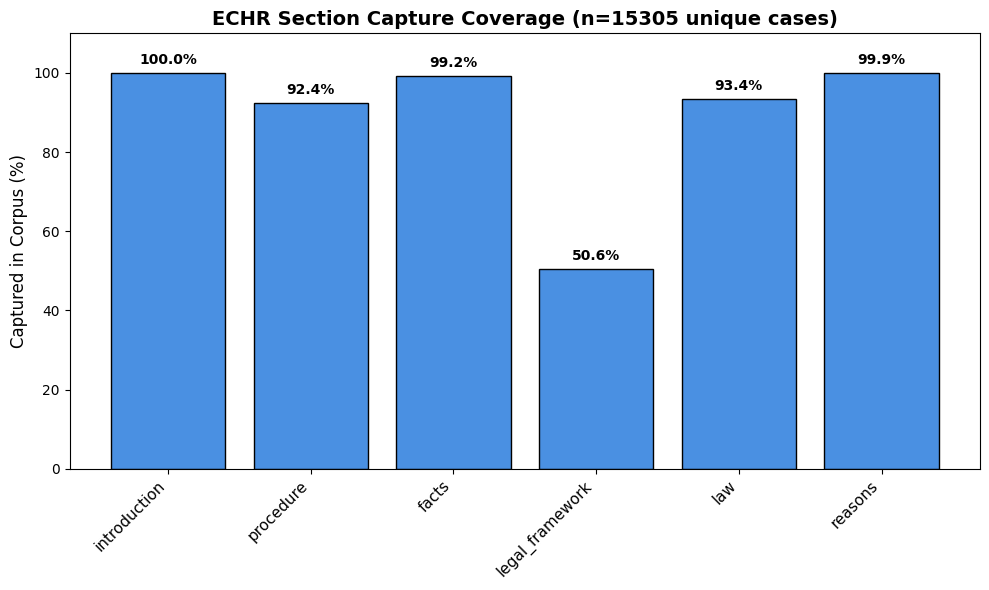

Capture coverage graph generated and saved as 'corpus_coverage_chart.png'.


In [1]:
import json
import matplotlib.pyplot as plt

def analyze_corpus_coverage(jsonl_filepath, output_report_path="missing_sections_report.json"):
    """
    Scans a master ECHR .jsonl file, computes section coverage on latest records
    per itemid, and exports a JSON report of cases with missing sections.
    """
    total_lines = 0
    latest_by_case = {}
    
    print(f"Scanning {jsonl_filepath}...")
    
    # 1. Stream the JSONL file line-by-line and keep the latest record per itemid
    try:
        with open(jsonl_filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                
                case_data = json.loads(line)
                total_lines += 1
                case_id = case_data.get("itemid", f"row_{total_lines}")
                latest_by_case[case_id] = case_data
                
                if total_lines % 10000 == 0:
                    print(f"Scanned {total_lines} lines...")
                    
    except FileNotFoundError:
        print(f"Error: Could not find the file at {jsonl_filepath}")
        return

    total_cases = len(latest_by_case)
    
    # Track how many unique cases successfully populated each core section
    section_counts = {
        "introduction": 0,
        "procedure": 0,
        "facts": 0,
        "legal_framework": 0,
        "law": 0,
        "reasons": 0
    }
    
    # Dictionary to hold our diagnostic report
    missing_report = {}
    
    # 2. Evaluate each core section on deduped corpus
    for case_id, case_data in latest_by_case.items():
        missing_in_this_case = []
        chunks = case_data.get('text_chunks', {})
        
        for section in section_counts.keys():
            text = chunks.get(section, "")
            if len(text.strip()) > 15:
                section_counts[section] += 1
            else:
                missing_in_this_case.append(section)
                
        if missing_in_this_case:
            missing_report[case_id] = missing_in_this_case

    # 3. Export the JSON diagnostic report
    with open(output_report_path, 'w', encoding='utf-8') as f:
        json.dump(missing_report, f, indent=4)
        
    print(f"\nScan complete! Total lines scanned: {total_lines}")
    print(f"Unique cases analyzed (latest record per itemid): {total_cases}")
    print(f"Diagnostic report saved to: {output_report_path}")

    # 4. Generate the capture coverage graph
    if total_cases == 0:
        print("No cases found to graph.")
        return
        
    sections = list(section_counts.keys())
    captured_percentages = [(count / total_cases) * 100 for count in section_counts.values()]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(sections, captured_percentages, color='#4A90E2', edgecolor='black')
    
    plt.title(f'ECHR Section Capture Coverage (n={total_cases} unique cases)', fontsize=14, fontweight='bold')
    plt.ylabel('Captured in Corpus (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.ylim(0, 110)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    
    print("Capture coverage graph generated and saved as 'corpus_coverage_chart.png'.")

analyze_corpus_coverage('../data/processed_json/echr_corpus.jsonl')

Starting decision extraction: writing fresh corpus to ../data/processed_json\echr_decisions_corpus.jsonl...
Successfully processed 500 decision cases...
Successfully processed 1000 decision cases...
Successfully processed 1500 decision cases...
Successfully processed 2000 decision cases...
Successfully processed 2500 decision cases...
Successfully processed 3000 decision cases...
Successfully processed 3500 decision cases...
Successfully processed 4000 decision cases...
Successfully processed 4500 decision cases...
Successfully processed 5000 decision cases...
Error processing ..\data\decision_text\001-148560.html: keys must be str, int, float, bool or None, not tuple
Successfully processed 5500 decision cases...
Successfully processed 6000 decision cases...
Successfully processed 6500 decision cases...
Error processing ..\data\decision_text\001-163829.html: keys must be str, int, float, bool or None, not tuple
Successfully processed 7000 decision cases...
Successfully processed 7500 d

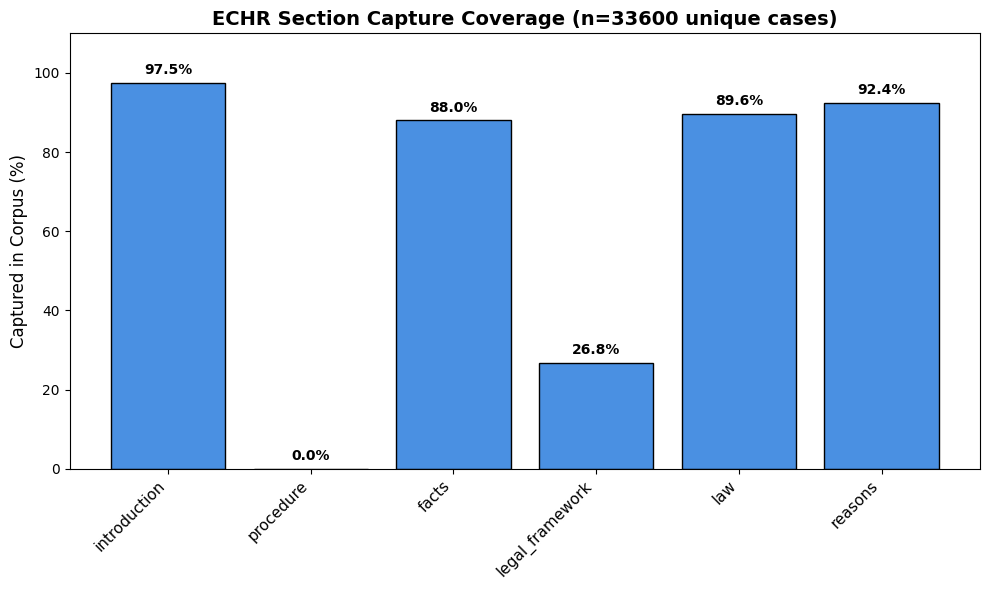

Capture coverage graph generated and saved as 'corpus_coverage_chart.png'.


In [ ]:
# Run the same extraction pipeline on decision cases and chart coverage
import os
import json

decision_path = "../data/decision_text"
output_path = "../data/processed_json"
decision_jsonl_path = os.path.join(output_path, "echr_decisions_corpus.jsonl")
decision_missing_report_path = "missing_sections_report_decisions.json"

os.makedirs(output_path, exist_ok=True)

success_count = 0
skipped_empty_count = 0
error_count = 0

print(f"Starting decision extraction: writing fresh corpus to {decision_jsonl_path}...")

with open(decision_jsonl_path, 'w', encoding='utf-8') as outfile:
    for html_path, soup in iter_case_soups(input_folder=decision_path):
        try:
            raw_html = str(soup)
            clean_data = process_echr_document(raw_html, is_decision=True)

            # Exclude historically empty conversion outputs (no extractable text layer)
            if not (clean_data.get("full_text") or "").strip():
                skipped_empty_count += 1
                continue

            base_name = os.path.basename(html_path)
            itemid = base_name.replace('.html', '')
            clean_data["itemid"] = itemid

            outfile.write(json.dumps(clean_data, ensure_ascii=False) + "\n")
            success_count += 1

            if success_count % 500 == 0:
                print(f"Successfully processed {success_count} decision cases...")
        except Exception as e:
            print(f"Error processing {html_path}: {e}")
            error_count += 1

print(f"\nDecision extraction complete! Success: {success_count} | Skipped empty: {skipped_empty_count} | Errors: {error_count}")

# Generate decisions-only capture coverage chart + missing report
analyze_corpus_coverage(
    decision_jsonl_path,
    output_report_path=decision_missing_report_path,
)

Found 2537 decision cases missing reasons
Re-processing ALL with updated patterns...
Reprocessed 500 cases...
Reprocessed 1000 cases...
Reprocessed 1500 cases...
Reprocessed 2000 cases...
Reprocessed 2500 cases...

Reprocessing complete! Updated: 2537 | Errors: 0
Writing updated corpus to ../data/processed_json/echr_decisions_corpus.jsonl...
Regenerating coverage report...
Scanning ../data/processed_json/echr_decisions_corpus.jsonl...
Scanned 10000 lines...
Scanned 20000 lines...
Scanned 30000 lines...

Scan complete! Total lines scanned: 33600
Unique cases analyzed (latest record per itemid): 33600
Diagnostic report saved to: missing_sections_report_decisions.json


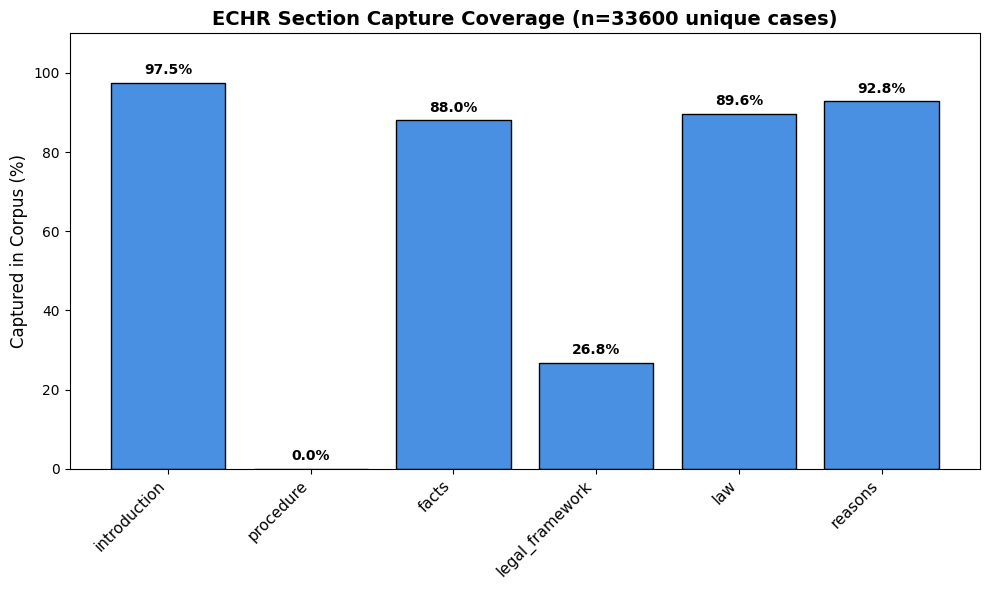

Capture coverage graph generated and saved as 'corpus_coverage_chart.png'.


In [ ]:
# Targeted reprocess for ALL decisions with missing reasons using new patterns
import os
import json
from pathlib import Path

decision_jsonl_path = "../data/processed_json/echr_decisions_corpus.jsonl"
decision_missing_report_path = "missing_sections_report_decisions.json"
output_path = "../data/processed_json"

# Load the current missing report
with open(decision_missing_report_path, 'r') as f:
    missing_report = json.load(f)

# Get case IDs missing reasons
missing_reasons_ids = sorted([
    case_id for case_id, missing in missing_report.items()
    if "reasons" in missing
])

print(f"Found {len(missing_reasons_ids)} decision cases missing reasons")
print(f"Re-processing ALL with updated patterns...")

# Load existing corpus
latest_by_case = {}
with open(decision_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        record = json.loads(line)
        itemid = record.get("itemid")
        if itemid:
            latest_by_case[itemid] = record

# Re-process all missing reasons cases with new parsing
html_base = "../data/decision_text"
reprocessed_count = 0
skipped_empty_count = 0
error_count = 0

for case_id in missing_reasons_ids:
    html_path = Path(html_base) / f"{case_id}.html"

    try:
        if html_path.exists():
            raw_html = html_path.read_text(encoding='utf-8', errors='ignore')
            clean_data = process_echr_document(raw_html, is_decision=True)

            # Keep empty-text cases excluded from corpus
            if not (clean_data.get("full_text") or "").strip():
                latest_by_case.pop(case_id, None)
                skipped_empty_count += 1
                continue

            clean_data["itemid"] = case_id
            latest_by_case[case_id] = clean_data
            reprocessed_count += 1

            if reprocessed_count % 500 == 0:
                print(f"Reprocessed {reprocessed_count} cases...")
    except Exception as e:
        error_count += 1

print(f"\nReprocessing complete! Updated: {reprocessed_count} | Skipped empty: {skipped_empty_count} | Errors: {error_count}")

# Write back updated corpus
print(f"Writing updated corpus to {decision_jsonl_path}...")
with open(decision_jsonl_path, 'w', encoding='utf-8') as f:
    for itemid, record in latest_by_case.items():
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Regenerating coverage report...")
analyze_corpus_coverage(decision_jsonl_path, output_report_path=decision_missing_report_path)

In [ ]:
# One-time cleanup: remove already-ingested empty-text decisions from current corpus
import json

decision_jsonl_path = "../data/processed_json/echr_decisions_corpus.jsonl"
decision_missing_report_path = "missing_sections_report_decisions.json"

records = []
removed_empty = 0

with open(decision_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        record = json.loads(line)
        if (record.get("full_text") or "").strip():
            records.append(record)
        else:
            removed_empty += 1

with open(decision_jsonl_path, 'w', encoding='utf-8') as f:
    for record in records:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Removed empty-text cases: {removed_empty}")
print(f"Remaining decision cases: {len(records)}")

print("Regenerating missing-sections report after cleanup...")
analyze_corpus_coverage(decision_jsonl_path, output_report_path=decision_missing_report_path)

In [12]:
# Check how many cases now have reasons after the targeted reprocess
import json

with open("missing_sections_report_decisions.json", 'r') as f:
    updated_report = json.load(f)

# Count still missing vs recovered
still_missing_reasons = sum(1 for case_id, missing in updated_report.items() if "reasons" in missing)
total_cases = len(updated_report)

print(f"Decision cases coverage AFTER targeted reprocess:")
print(f"  Total cases: {total_cases}")
print(f"  Still missing reasons: {still_missing_reasons}")
print(f"  Recovered: {2537 - still_missing_reasons}")
print(f"  Recovery rate: {((2537 - still_missing_reasons) / 2537 * 100):.1f}%")
print(f"  Overall coverage: {((total_cases - still_missing_reasons) / total_cases * 100):.1f}%")

# Sample one case that was previously missing to verify
test_case = "001-3081"  # The case we looked at earlier
if test_case in updated_report:
    is_missing = "reasons" in updated_report[test_case]
    print(f"\nTest case {test_case}: {'STILL MISSING' if is_missing else 'NOW HAS REASONS ✓'}")

Decision cases coverage AFTER targeted reprocess:
  Total cases: 33600
  Still missing reasons: 2422
  Recovered: 115
  Recovery rate: 4.5%
  Overall coverage: 92.8%

Test case 001-3081: NOW HAS REASONS ✓


In [14]:
# Verify the recovered case has valid reasons content
import json
from pathlib import Path

decision_jsonl_path = "../data/processed_json/echr_decisions_corpus.jsonl"

# Find case 001-3081 in the corpus
with open(decision_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        if record.get("itemid") == "001-3081":
            reasons = record.get("text_chunks", {}).get("reasons", "").strip()
            if reasons:
                print("✓ Case 001-3081 RECOVERED")
                print(f"Reasons length: {len(reasons)} chars")
                print(f"First 400 chars of reasons:\n{reasons[:400]}")
                print(f"\n... [middle content] ...\n")
                print(f"Last 200 chars:\n{reasons[-200:]}")
            break

✓ Case 001-3081 RECOVERED
Reasons length: 369 chars
First 400 chars of reasons:
Now therefore the Commission

**1.** Declares inadmissible the first applicant's complaints set out under
1 (i) to (iv) of the statement of facts;
**2.** Decides to adjourn its examination of the admissibility of the first
applicant's complaint set out under 1 (v) of the statement of facts;
**3.** Declares inadmissible all the complaints made by the second
applicant.

... [middle content] ...

Last 200 chars:
urn its examination of the admissibility of the first
applicant's complaint set out under 1 (v) of the statement of facts;
**3.** Declares inadmissible all the complaints made by the second
applicant.


In [15]:
# Export ONLY the current missing reasons cases for investigation
import json
from pathlib import Path

with open("missing_sections_report_decisions.json", 'r') as f:
    updated_report = json.load(f)

# Get only cases still missing reasons
still_missing = sorted([
    case_id for case_id, missing in updated_report.items() 
    if "reasons" in missing
])

print(f"Current MISSING reasons cases: {len(still_missing)}")
print(f"\nFirst 20: {still_missing[:20]}")

# Save to a reference file
with open("current_missing_reasons_cases.txt", 'w') as f:
    for case_id in still_missing:
        f.write(f"{case_id}\n")

print(f"\nSaved {len(still_missing)} case IDs to current_missing_reasons_cases.txt")

Current MISSING reasons cases: 2422

First 20: ['001-101061', '001-103586', '001-1045', '001-1047', '001-106041', '001-108081', '001-108082', '001-108452', '001-109007', '001-110435', '001-112565', '001-115345', '001-115598', '001-116105', '001-117006', '001-124363', '001-124510', '001-125984', '001-126017', '001-126071']

Saved 2422 case IDs to current_missing_reasons_cases.txt


In [17]:
# Create fresh review folder with CURRENT missing reasons cases
import json
from pathlib import Path

decision_jsonl_path = "../data/processed_json/echr_decisions_corpus.jsonl"
review_dir = Path("../data/processed_json/decision_missing_section_review_current/reasons")
review_dir.mkdir(parents=True, exist_ok=True)

# Load corpus
corpus_by_id = {}
with open(decision_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        itemid = record.get("itemid")
        if itemid:
            corpus_by_id[itemid] = record

# Extract all current missing reason cases
with open("missing_sections_report_decisions.json", 'r') as f:
    updated_report = json.load(f)

still_missing = sorted([
    case_id for case_id, missing in updated_report.items() 
    if "reasons" in missing
])

print(f"Exporting {len(still_missing)} current missing reasons cases...")

# Export each case
exported = 0
for case_id in still_missing:
    if case_id in corpus_by_id:
        record = corpus_by_id[case_id]
        # Add full_text for context
        export_data = {
            "itemid": case_id,
            "full_text": record.get("full_text", ""),
            "text_chunks": record.get("text_chunks", {}),
            "tables": record.get("tables", [])
        }
        export_path = review_dir / f"{case_id}.json"
        with open(export_path, 'w', encoding='utf-8') as f:
            json.dump(export_data, f, ensure_ascii=False, indent=2)
        exported += 1
        
        if exported % 500 == 0:
            print(f"  Exported {exported}/{len(still_missing)}...")

print(f"\n✓ Exported {exported} cases to: {review_dir}")
print(f"Ready for investigation!")

Exporting 2422 current missing reasons cases...
  Exported 500/2422...
  Exported 1000/2422...
  Exported 1500/2422...
  Exported 2000/2422...

✓ Exported 2422 cases to: ..\data\processed_json\decision_missing_section_review_current\reasons
Ready for investigation!


In [19]:
# Detect language of documents in the corpus
from pathlib import Path
import json
import re

decision_jsonl_path = "../data/processed_json/echr_decisions_corpus.jsonl"

# Simple language detection based on keywords
language_indicators = {
    'it': ['CORTE EUROPEA', 'In fatto', 'In diritto', 'Ricorso', 'Dispositivo'],  # Italian
    'es': ['Demanda', 'Sentencia', 'Considerando', 'Recurso'],  # Spanish
    'de': ['Beschwerde', 'Entscheidung', 'Tatsachen', 'Recht'],  # German
    'pt': ['Recurso', 'Acórdão', 'Factos', 'Direito'],  # Portuguese
    'pl': ['Skarga', 'Orzeczenie', 'Fakty', 'Prawo'],  # Polish
}

language_counts = {}
non_english_french = []

with open(decision_jsonl_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i > 2000:  # Sample first 2000
            break
        record = json.loads(line)
        full_text = record.get("full_text", "")[:1000]  # First 1000 chars
        
        detected = None
        for lang, keywords in language_indicators.items():
            if any(kw in full_text for kw in keywords):
                detected = lang
                break
        
        if not detected:
            detected = 'en/fr'  # Default to English/French if no other detected
        
        language_counts[detected] = language_counts.get(detected, 0) + 1
        
        if detected not in ['en/fr']:
            non_english_french.append({
                "itemid": record.get("itemid"),
                "detected_lang": detected,
                "sample": full_text[:150]
            })

print(f"Language distribution (first 2000 cases):") 
for lang, count in sorted(language_counts.items(), key=lambda x: -x[1]):
    pct = (count / 2000 * 100)
    print(f"  {lang}: {count} ({pct:.1f}%)")

print(f"\n⚠ Non-English/French cases found: {len(non_english_french)}")
print(f"Proportion: {len(non_english_french)/2000*100:.1f}%")

if non_english_french:
    print(f"\nExamples:")
    for ex in non_english_french[:10]:
        print(f"  {ex['itemid']} ({ex['detected_lang']}): {ex['sample'][:80]}...")

Language distribution (first 2000 cases):
  en/fr: 2001 (100.0%)

⚠ Non-English/French cases found: 0
Proportion: 0.0%


In [21]:
# Check the raw HTML for case 001-185151 to see what's there
from pathlib import Path

html_path = Path("../data/decision_text/001-185151.html")

if html_path.exists():
    raw_html = html_path.read_text(encoding='utf-8', errors='ignore')
    
    # Check for language markers
    has_italian = "CORTE EUROPEA DEI DIRITTI DELL'UOMO" in raw_html
    has_french = "COUR EUROPÉENNE DES DROITS DE L'HOMME" in raw_html
    has_english = "EUROPEAN COURT OF HUMAN RIGHTS" in raw_html
    
    print(f"Raw HTML for case 001-185151:")
    print(f"  Has Italian markers: {has_italian}")
    print(f"  Has French markers: {has_french}")
    print(f"  Has English markers: {has_english}")
    print(f"  Total size: {len(raw_html)} chars")
    
    # Show first 1000 chars around title area
    print(f"\nFirst 1000 chars of HTML:")
    print(raw_html[:1000])
else:
    print(f"File not found: {html_path}")

Raw HTML for case 001-185151:
  Has Italian markers: False
  Has French markers: False
  Has English markers: False
  Total size: 17683 chars

First 1000 chars of HTML:
<style>
 .s800EAC49 { font-size:12pt }
.sD1EC9430 { margin-right:12pt; margin-left:12pt }
.s65B66A85 { margin-top:12pt; margin-bottom:12pt }
.s598389F7 { margin-top:0pt; margin-bottom:0pt; text-align:center; font-size:10pt }
.sBB9EE52A { font-family:Arial }
.sD25A6C22 { margin:14pt 12pt; text-align:justify }
.sE56A51D4 { margin-top:14pt; margin-bottom:14pt; text-align:center }
.s29100277 { font-family:Arial; font-weight:bold }
.s189D71EE { margin-top:14pt; margin-bottom:14pt }
.sA36B60A1 { font-family:Arial; font-style:italic }
.sF2DE4D34 { border:0.75pt solid #000000 }
.sF150095B { padding:1.5pt; vertical-align:middle }
.s2EF62ED2 { margin-top:0pt; margin-bottom:0pt; font-size:12pt }
.sC5A1AD1E { font-family:Arial; font-size:11pt; font-weight:bold; color:#333333 }
.s3B8B4C93 { border-style:solid; border-width:0.75pt; p

In [7]:
from pathlib import Path
import json
import re
import textwrap

# Decisions review: missing cases + possible headers for introduction, facts, reasons
report_path = Path("../data/missing_sections_report_decisions.json")
corpus_path = Path("../data/processed_json/echr_decisions_corpus.jsonl")
export_root = Path("../data/processed_json/decision_missing_section_review")
export_root.mkdir(parents=True, exist_ok=True)

preview_chars = 900

section_config = {
    "introduction": {
        "pattern": re.compile(
            r"\b(DECISION|D[ÉE]CISION|FIRST\s+SECTION|SECOND\s+SECTION|THIRD\s+SECTION|FOURTH\s+SECTION|FIFTH\s+SECTION|GRAND\s+CHAMBER|CHAMBER)\b",
            re.IGNORECASE,
        ),
    },
    "facts": {
        "pattern": re.compile(
            r"\b(AS\s+TO\s+THE\s+FACTS|THE\s+FACTS|EN\s+FAIT|LES\s+FAITS|STATEMENT\s+OF\s+FACTS|EXPOS[EÉ]\s+DES\s+FAITS|THE\s+CIRCUMSTANCES\s+OF\s+THE\s+CASES?|CIRCONSTANCES\s+DE\s+L['’]AFFAIRE)\b",
            re.IGNORECASE,
        ),
    },
    "reasons": {
        "pattern": re.compile(
            r"\b(FOR\s+THESE\s+REAS\s*O\s*NS|PAR\s+CES\s+MOTIFS|F\s*O\s*R\s+T\s*H\s*E\s*S\s*E\s+R\s*E\s*A\s*S\s*O\s*N\s*S|OPERATIVE\s+PART|DISPOSITIF)\b",
            re.IGNORECASE,
        ),
    },
}

with report_path.open("r", encoding="utf-8") as f:
    missing_report = json.load(f)

latest_by_case = {}
with corpus_path.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        record = json.loads(line)
        itemid = record.get("itemid")
        if itemid:
            latest_by_case[itemid] = record

print(f"Loaded unique decision corpus records: {len(latest_by_case)}")

for section_name, cfg in section_config.items():
    missing_ids = sorted([
        case_id for case_id, missing_sections in missing_report.items()
        if section_name in missing_sections
    ])

    section_dir = export_root / section_name
    section_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    print("\n" + "=" * 110)
    print(f"Reviewing decision section: {section_name}")
    print(f"Cases flagged missing '{section_name}': {len(missing_ids)}")

    for case_id in missing_ids:
        record = latest_by_case.get(case_id)

        if record is None:
            rows.append({
                "itemid": case_id,
                "status": "not_found_in_corpus",
                "possible_header": False,
                "possible_header_text": None,
                "possible_header_context": None,
                "section_length": 0,
            })
            continue

        chunks = record.get("text_chunks", {})
        section_text = chunks.get(section_name, "")
        full_text = record.get("full_text", "")

        match = cfg["pattern"].search(full_text)
        possible_header = bool(match)
        possible_header_text = match.group(0) if match else None

        possible_header_context = None
        if match:
            start = max(0, match.start() - 250)
            end = min(len(full_text), match.end() + 500)
            possible_header_context = re.sub(r"\s+", " ", full_text[start:end]).strip()

        export_payload = {
            "itemid": case_id,
            "section": section_name,
            "missing_sections_reported": missing_report.get(case_id, []),
            "possible_header": possible_header,
            "possible_header_text": possible_header_text,
            "possible_header_context": possible_header_context,
            "section_length": len(section_text.strip()),
            "section_text": section_text,
            "text_chunks": chunks,
            "full_text": full_text,
            "tables": record.get("tables", []),
        }
        with (section_dir / f"{case_id}.json").open("w", encoding="utf-8") as f:
            json.dump(export_payload, f, ensure_ascii=False, indent=2)

        rows.append({
            "itemid": case_id,
            "status": "found_in_corpus",
            "possible_header": possible_header,
            "possible_header_text": possible_header_text,
            "possible_header_context": possible_header_context,
            "section_length": len(section_text.strip()),
        })

    summary_path = section_dir / "summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(rows, f, ensure_ascii=False, indent=2)

    possible_header_count = sum(1 for r in rows if r["possible_header"])
    print(f"Possible header=True: {possible_header_count}/{len(rows)}")
    print(f"Exported case files: {len(rows)}")
    print(f"Summary path: {summary_path}")

    for row in rows[:5]:
        print("-" * 70)
        print(f"{row['itemid']} | possible_header={row['possible_header']} | section_length={row['section_length']}")
        if row["possible_header_context"]:
            print(textwrap.shorten(row["possible_header_context"], width=preview_chars, placeholder=" ..."))

Loaded unique decision corpus records: 33600

Reviewing decision section: introduction
Cases flagged missing 'introduction': 835
Possible header=True: 236/835
Exported case files: 835
Summary path: ..\data\processed_json\decision_missing_section_review\introduction\summary.json
----------------------------------------------------------------------
001-108081 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-108082 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-110210 | possible_header=True | section_length=3
fy that the works were compliant or to amend the planning permission ( concessione in sanatoria ) . In a memorandum dated 13 May 1996, the Municipality informed the applicant company that it had decided to defer the examination of this point until a decision had been taken by the Piedmont Regional Authority. The applicant company then issued pro

In [18]:
from pathlib import Path
import json
import re
import textwrap

# Paths
report_path = Path("../data/missing_sections_report.json")
corpus_path = Path("../data/processed_json/echr_corpus.jsonl")
export_dir = Path("../data/processed_json/facts_missing_review")
export_dir.mkdir(parents=True, exist_ok=True)

# Display controls
preview_chars = 1000          # full-text preview per case in notebook output
facts_preview_chars = 500     # extracted facts-chunk preview per case in notebook output

# ---------------------------------------------------------
# 1) Load report and collect cases missing 'facts'
# ---------------------------------------------------------
with report_path.open("r", encoding="utf-8") as f:
    missing_report = json.load(f)

facts_missing_ids = sorted([
    case_id for case_id, missing_sections in missing_report.items()
    if "facts" in missing_sections
])

print(f"Cases flagged as missing 'facts': {len(facts_missing_ids)}")
if not facts_missing_ids:
    print("No cases with missing 'facts' were found in missing_sections_report.json")
else:
    facts_missing_set = set(facts_missing_ids)
    matched_records = {}

    # ---------------------------------------------------------
    # 2) Stream corpus and collect only the flagged cases
    # ---------------------------------------------------------
    with corpus_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            itemid = record.get("itemid")
            if itemid in facts_missing_set:
                matched_records[itemid] = record

    print(f"Matched in corpus: {len(matched_records)}/{len(facts_missing_ids)}")

    # Simple heading probes to detect whether facts-like headings may exist in full_text
    facts_heading_pattern = re.compile(
        r"\b(AS\s+TO\s+THE\s+FACTS|THE\s+FACTS|EN\s+FAIT|LES\s+FAITS|"
        r"THE\s+PARTICULAR\s+CIRCUMSTANCES\s+OF\s+THE\s+CASES?|"
        r"THE\s+CIRCUMSTANCES\s+OF\s+THE\s+CASES?|"
        r"CIRCONSTANCES\s+DE\s+L['’]AFFAIRE|"
        r"EXPOS[EÉ]\s+DES\s+FAITS)\b",
        re.IGNORECASE,
    )

    summary_rows = []

    # ---------------------------------------------------------
    # 3) Print + export case-by-case review files
    # ---------------------------------------------------------
    for case_id in facts_missing_ids:
        record = matched_records.get(case_id)
        print("\n" + "=" * 110)
        print(f"CASE: {case_id}")

        if record is None:
            print("Status: Not found in corpus JSONL")
            summary_rows.append({
                "itemid": case_id,
                "status": "not_found_in_corpus",
                "facts_like_heading_found": False,
                "facts_like_heading_text": None,
                "facts_like_heading_context": None,
                "facts_length": 0,
            })
            continue

        chunks = record.get("text_chunks", {})
        facts_chunk = chunks.get("facts", "")
        full_text = record.get("full_text", "")

        section_lengths = {
            "introduction": len(chunks.get("introduction", "").strip()),
            "procedure": len(chunks.get("procedure", "").strip()),
            "facts": len(facts_chunk.strip()),
            "legal_framework": len(chunks.get("legal_framework", "").strip()),
            "law": len(chunks.get("law", "").strip()),
            "reasons": len(chunks.get("reasons", "").strip()),
            "appendix": len(chunks.get("appendix", "").strip()),
        }

        match = facts_heading_pattern.search(full_text)
        has_facts_heading = bool(match)
        matched_heading_text = match.group(0) if match else None

        heading_context = None
        if match:
            start = max(0, match.start() - 250)
            end = min(len(full_text), match.end() + 500)
            heading_context = re.sub(r"\s+", " ", full_text[start:end]).strip()

        print("Section lengths:")
        print(f"  introduction:    {section_lengths['introduction']}")
        print(f"  procedure:       {section_lengths['procedure']}")
        print(f"  facts:           {section_lengths['facts']}")
        print(f"  legal_framework: {section_lengths['legal_framework']}")
        print(f"  law:             {section_lengths['law']}")
        print(f"  reasons:         {section_lengths['reasons']}")
        print(f"  appendix:        {section_lengths['appendix']}")

        print(f"Facts-like heading found in full_text: {has_facts_heading}")
        print(f"Facts-like heading text: {matched_heading_text}")

        print("\n[Extracted facts chunk preview]")
        facts_preview = textwrap.shorten(
            re.sub(r"\s+", " ", facts_chunk.strip()),
            width=facts_preview_chars,
            placeholder=" ...",
        )
        print(facts_preview if facts_preview else "<EMPTY>")

        print("\n[Full text preview]")
        full_preview = textwrap.shorten(
            re.sub(r"\s+", " ", full_text.strip()),
            width=preview_chars,
            placeholder=" ...",
        )
        print(full_preview if full_preview else "<EMPTY>")

        if heading_context:
            print("\n[Context around first facts-like heading]")
            print(heading_context)

        export_payload = {
            "itemid": case_id,
            "missing_sections_reported": missing_report.get(case_id, []),
            "status": "found_in_corpus",
            "facts_like_heading_found": has_facts_heading,
            "facts_like_heading_text": matched_heading_text,
            "facts_like_heading_context": heading_context,
            "section_lengths": section_lengths,
            "text_chunks": chunks,
            "full_text": full_text,
            "tables": record.get("tables", []),
        }

        export_path = export_dir / f"{case_id}.json"
        with export_path.open("w", encoding="utf-8") as f:
            json.dump(export_payload, f, ensure_ascii=False, indent=2)

        summary_rows.append({
            "itemid": case_id,
            "status": "found_in_corpus",
            "facts_like_heading_found": has_facts_heading,
            "facts_like_heading_text": matched_heading_text,
            "facts_like_heading_context": heading_context,
            "facts_length": section_lengths["facts"],
        })

    summary_path = export_dir / "facts_missing_summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary_rows, f, ensure_ascii=False, indent=2)

    print("\n" + "-" * 110)
    print(f"Export complete. Review folder: {export_dir}")
    print(f"Summary file: {summary_path}")

Cases flagged as missing 'facts': 486
Matched in corpus: 486/486

CASE: 001-102844
Section lengths:
  introduction:    22369
  procedure:       1439
  facts:           0
  legal_framework: 195
  law:             6696
  reasons:         1754
  appendix:        24
Facts-like heading found in full_text: True
Facts-like heading text: Les faits

[Extracted facts chunk preview]
<EMPTY>

[Full text preview]
DEUXIÈME SECTION AFFAIRE SALVATORE ET AUTRES c. ITALIE ( Requêtes n os 27036/03, 34885/03, 37903/03 et 37905/03) ARRÊT STRASBOURG 18 janvier 2011 Cet arrêt est définitif. Il peut subir des retouches de forme. En l'affaire Salvatore et autres c. Italie, La Cour européenne des droits de l'homme (deuxième section), siégeant en un Comité composé de : Danutė Jočienė, présidente, Nona Tsotsoria, Guido Raimondi, juges, et de Françoise Elens-Passos, greffière adjointe de section, Après en avoir délibéré en chambre du conseil le 14 décembre 2010, Rend l'arrêt que voici, adopté à cette date : PROCÉD

In [22]:
# Targeted reprocess: replace existing records for cases currently flagged as missing 'facts'
from pathlib import Path
import json

report_path = Path("../data/missing_sections_report.json")
judgment_path = Path("../data/judgment_text")
jsonl_path = Path("../data/processed_json/echr_corpus.jsonl")

with report_path.open("r", encoding="utf-8") as f:
    missing_report = json.load(f)

target_case_ids = sorted([
    case_id for case_id, missing_sections in missing_report.items()
    if "facts" in missing_sections
])

print(f"Target cases (missing facts): {len(target_case_ids)}")

# 1) Load existing corpus and keep latest record per itemid
existing_records = {}
existing_lines = 0
if jsonl_path.exists():
    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            existing_lines += 1
            record = json.loads(line)
            case_id = record.get("itemid", f"row_{existing_lines}")
            existing_records[case_id] = record

print(f"Loaded corpus lines: {existing_lines}")
print(f"Loaded unique cases: {len(existing_records)}")

processed = 0
missing_html = 0
errors = 0
replaced = 0
added = 0

# 2) Reprocess only target cases and update in-memory corpus
for case_id in target_case_ids:
    html_file = judgment_path / f"{case_id}.html"

    if not html_file.exists():
        missing_html += 1
        continue

    try:
        raw_html = html_file.read_text(encoding="utf-8", errors="ignore")
        clean_data = process_echr_document(raw_html)
        clean_data["itemid"] = case_id

        if case_id in existing_records:
            replaced += 1
        else:
            added += 1

        existing_records[case_id] = clean_data
        processed += 1
    except Exception as e:
        print(f"Error processing {case_id}: {e}")
        errors += 1

# 3) Rewrite corpus once so each itemid appears only once
with jsonl_path.open("w", encoding="utf-8") as outfile:
    for record in existing_records.values():
        outfile.write(json.dumps(record, ensure_ascii=False) + "\n")

print(
    f"Targeted reprocess complete. Updated: {processed} | "
    f"Replaced: {replaced} | Added: {added} | "
    f"Missing HTML: {missing_html} | Errors: {errors}"
)
print(f"Rewritten corpus unique case count: {len(existing_records)}")

Target cases (missing facts): 130
Loaded corpus lines: 16375
Loaded unique cases: 15304
Targeted reprocess complete. Updated: 130 | Replaced: 130 | Added: 0 | Missing HTML: 0 | Errors: 0
Rewritten corpus unique case count: 15304


In [24]:
from pathlib import Path
import json
import re
import textwrap

report_path = Path("../data/missing_sections_report.json")
corpus_path = Path("../data/processed_json/echr_corpus.jsonl")
export_root = Path("../data/processed_json/missing_section_review")
export_root.mkdir(parents=True, exist_ok=True)

preview_chars = 900
section_preview_chars = 500

section_config = {
    "procedure": {
        "pattern": re.compile(
            r"\\b(PROC[EÉ]DURE|PROCEDURE)\\b",
            re.IGNORECASE,
        ),
        "only_possible_header": False,
    },
    "law": {
        "pattern": re.compile(
            r"\\b(AS\\s+TO\\s+THE\\s+LAW|THE\\s+LAW|EN\\s+DROIT)\\b",
            re.IGNORECASE,
        ),
        "only_possible_header": False,
    },
    "legal_framework": {
        "pattern": re.compile(
            r"\\b(RELEVANT\\s+(?:DOMESTIC|INTERNATIONAL|LEGAL)\\s+(?:LAW|FRAMEWORK|MATERIAL)|"
            r"CADRE\\s+JURIDIQUE|"
            r"(?:LE\\s+)?DROIT\\s+(?:ET\\s+LA\\s+PRATIQUE\\s+)?(?:INTERNES?|INTERNATIONAL|PERTINENTS?))\\b",
            re.IGNORECASE,
        ),
        "only_possible_header": True,
    },
}

with report_path.open("r", encoding="utf-8") as f:
    missing_report = json.load(f)

# Keep latest record per itemid in case the corpus ever contains duplicates again
latest_by_case = {}
with corpus_path.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        record = json.loads(line)
        itemid = record.get("itemid")
        if itemid:
            latest_by_case[itemid] = record

print(f"Loaded unique corpus records: {len(latest_by_case)}")

for section_name, cfg in section_config.items():
    missing_ids = sorted([
        case_id for case_id, missing_sections in missing_report.items()
        if section_name in missing_sections
    ])

    section_dir = export_root / section_name
    section_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    print("\n" + "=" * 110)
    print(f"Reviewing section: {section_name}")
    print(f"Cases flagged missing '{section_name}': {len(missing_ids)}")

    for case_id in missing_ids:
        record = latest_by_case.get(case_id)

        if record is None:
            rows.append({
                "itemid": case_id,
                "status": "not_found_in_corpus",
                "possible_header": False,
                "possible_header_text": None,
                "possible_header_context": None,
                "section_length": 0,
                "included_in_export": False,
            })
            continue

        chunks = record.get("text_chunks", {})
        section_text = chunks.get(section_name, "")
        full_text = record.get("full_text", "")

        match = cfg["pattern"].search(full_text)
        possible_header = bool(match)
        possible_header_text = match.group(0) if match else None

        possible_header_context = None
        if match:
            start = max(0, match.start() - 250)
            end = min(len(full_text), match.end() + 500)
            possible_header_context = re.sub(r"\s+", " ", full_text[start:end]).strip()

        include_case = possible_header if cfg["only_possible_header"] else True

        row = {
            "itemid": case_id,
            "status": "found_in_corpus",
            "possible_header": possible_header,
            "possible_header_text": possible_header_text,
            "possible_header_context": possible_header_context,
            "section_length": len(section_text.strip()),
            "included_in_export": include_case,
        }
        rows.append(row)

        if include_case:
            export_payload = {
                "itemid": case_id,
                "section": section_name,
                "missing_sections_reported": missing_report.get(case_id, []),
                "possible_header": possible_header,
                "possible_header_text": possible_header_text,
                "possible_header_context": possible_header_context,
                "section_length": len(section_text.strip()),
                "section_text": section_text,
                "text_chunks": chunks,
                "full_text": full_text,
                "tables": record.get("tables", []),
            }
            with (section_dir / f"{case_id}.json").open("w", encoding="utf-8") as f:
                json.dump(export_payload, f, ensure_ascii=False, indent=2)

    if cfg["only_possible_header"]:
        summary_rows = [r for r in rows if r["possible_header"]]
    else:
        summary_rows = rows

    summary_path = section_dir / "summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary_rows, f, ensure_ascii=False, indent=2)

    possible_header_count = sum(1 for r in rows if r["possible_header"])
    included_count = sum(1 for r in rows if r["included_in_export"])

    print(f"Possible header=True: {possible_header_count}/{len(rows)}")
    print(f"Exported case files: {included_count}")
    print(f"Summary path: {summary_path}")

    # Print short previews for quick in-notebook checks
    for row in summary_rows[:5]:
        print("-" * 70)
        print(f"{row['itemid']} | possible_header={row['possible_header']} | section_length={row['section_length']}")
        if row["possible_header_context"]:
            print(textwrap.shorten(row["possible_header_context"], width=preview_chars, placeholder=" ..."))

Loaded unique corpus records: 15304

Reviewing section: procedure
Cases flagged missing 'procedure': 1168
Possible header=True: 0/1168
Exported case files: 1168
Summary path: ..\data\processed_json\missing_section_review\procedure\summary.json
----------------------------------------------------------------------
001-106439 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-109335 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-158243 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-193144 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-198804 | possible_header=False | section_length=0

Reviewing section: law
Cases flagged missing 'law': 1008
Possible header=True: 0/1008
Exported case files: 1008
Summary path: ..\d

In [ ]:
from pathlib import Path
import json
import re
import textwrap

report_path = Path("../data/missing_sections_report.json")
corpus_path = Path("../data/processed_json/echr_corpus.jsonl")
export_dir = Path("../data/processed_json/missing_section_review/reasons")
export_dir.mkdir(parents=True, exist_ok=True)

preview_chars = 900
section_name = "reasons"

reasons_heading_pattern = re.compile(
    r"\b(FOR\s+THESE\s+REAS\s*O\s*NS|PAR\s+CES\s+MOTIFS|F\s*O\s*R\s+T\s*H\s*E\s*S\s*E\s+R\s*E\s*A\s*S\s*O\s*N\s*S|OPERATIVE\s+PART|DISPOSITIF)\b",
    re.IGNORECASE,
)

with report_path.open("r", encoding="utf-8") as f:
    missing_report = json.load(f)

missing_ids = sorted([
    case_id for case_id, missing_sections in missing_report.items()
    if section_name in missing_sections
])

latest_by_case = {}
with corpus_path.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        record = json.loads(line)
        itemid = record.get("itemid")
        if itemid:
            latest_by_case[itemid] = record

print(f"Loaded unique corpus records: {len(latest_by_case)}")
print(f"Cases flagged missing '{section_name}': {len(missing_ids)}")

rows = []
exported = 0

for case_id in missing_ids:
    record = latest_by_case.get(case_id)

    if record is None:
        rows.append({
            "itemid": case_id,
            "status": "not_found_in_corpus",
            "possible_header": False,
            "possible_header_text": None,
            "possible_header_context": None,
            "section_length": 0,
        })
        continue

    chunks = record.get("text_chunks", {})
    section_text = chunks.get(section_name, "")
    full_text = record.get("full_text", "")

    match = reasons_heading_pattern.search(full_text)
    possible_header = bool(match)
    possible_header_text = match.group(0) if match else None

    possible_header_context = None
    if match:
        start = max(0, match.start() - 250)
        end = min(len(full_text), match.end() + 500)
        possible_header_context = re.sub(r"\s+", " ", full_text[start:end]).strip()

    export_payload = {
        "itemid": case_id,
        "section": section_name,
        "missing_sections_reported": missing_report.get(case_id, []),
        "possible_header": possible_header,
        "possible_header_text": possible_header_text,
        "possible_header_context": possible_header_context,
        "section_length": len(section_text.strip()),
        "section_text": section_text,
        "text_chunks": chunks,
        "full_text": full_text,
        "tables": record.get("tables", []),
    }
    with (export_dir / f"{case_id}.json").open("w", encoding="utf-8") as f:
        json.dump(export_payload, f, ensure_ascii=False, indent=2)
    exported += 1

    rows.append({
        "itemid": case_id,
        "status": "found_in_corpus",
        "possible_header": possible_header,
        "possible_header_text": possible_header_text,
        "possible_header_context": possible_header_context,
        "section_length": len(section_text.strip()),
    })

summary_path = export_dir / "summary.json"
with summary_path.open("w", encoding="utf-8") as f:
    json.dump(rows, f, ensure_ascii=False, indent=2)

possible_header_count = sum(1 for r in rows if r["possible_header"])
print(f"Possible header=True: {possible_header_count}/{len(rows)}")
print(f"Exported case files: {exported}")
print(f"Summary path: {summary_path}")

for row in rows[:5]:
    print("-" * 70)
    print(f"{row['itemid']} | possible_header={row['possible_header']} | section_length={row['section_length']}")
    if row["possible_header_context"]:
        print(textwrap.shorten(row["possible_header_context"], width=preview_chars, placeholder=" ..."))

Loaded unique corpus records: 15304
Cases flagged missing 'reasons': 46
Possible header=True: 42/46
Exported case files: 46
Summary path: ..\data\processed_json\missing_section_review\reasons\summary.json
----------------------------------------------------------------------
001-106439 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-177410 | possible_header=False | section_length=0
----------------------------------------------------------------------
001-233216 | possible_header=True | section_length=0
nts n’ont produit aucun document attestant de l’engagement de leurs clients à payer les honoraires indiqués (voir, a contrario , M.S.S. c. Belgique et Grèce [GC], n o 30696/09, § 414, CEDH 2011). La Cour rejette donc la demande formulée à ce titre. ​PAR CES MOTIFS, LA COUR, À L’UNANIMITÉ, Déclare le grief tiré de l’article 6 § 1 de la Convention recevable et le surplus de la requête irrecevable ; Dit qu’il y a eu viol

In [32]:
# Targeted reprocess: replace existing records for cases currently flagged as missing 'reasons'
from pathlib import Path
import json

report_path = Path("../data/missing_sections_report.json")
judgment_path = Path("../data/judgment_text")
jsonl_path = Path("../data/processed_json/echr_corpus.jsonl")

with report_path.open("r", encoding="utf-8") as f:
    missing_report = json.load(f)

target_case_ids = sorted([
    case_id for case_id, missing_sections in missing_report.items()
    if "reasons" in missing_sections
])

print(f"Target cases (missing reasons): {len(target_case_ids)}")

existing_records = {}
existing_lines = 0
if jsonl_path.exists():
    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            existing_lines += 1
            record = json.loads(line)
            case_id = record.get("itemid", f"row_{existing_lines}")
            existing_records[case_id] = record

processed = 0
missing_html = 0
errors = 0
replaced = 0
added = 0

for case_id in target_case_ids:
    html_file = judgment_path / f"{case_id}.html"
    if not html_file.exists():
        missing_html += 1
        continue

    try:
        raw_html = html_file.read_text(encoding="utf-8", errors="ignore")
        clean_data = process_echr_document(raw_html)
        clean_data["itemid"] = case_id

        if case_id in existing_records:
            replaced += 1
        else:
            added += 1

        existing_records[case_id] = clean_data
        processed += 1
    except Exception as e:
        print(f"Error processing {case_id}: {e}")
        errors += 1

with jsonl_path.open("w", encoding="utf-8") as outfile:
    for record in existing_records.values():
        outfile.write(json.dumps(record, ensure_ascii=False) + "\n")

print(
    f"Reasons reprocess complete. Updated: {processed} | "
    f"Replaced: {replaced} | Added: {added} | "
    f"Missing HTML: {missing_html} | Errors: {errors}"
)

Target cases (missing reasons): 46
Reasons reprocess complete. Updated: 46 | Replaced: 46 | Added: 0 | Missing HTML: 0 | Errors: 0
